# Local Outlier Factor (LOF) — An Illustrated Tour

> A point is anomalous when its **local density is much lower than its neighbors'**. LOF compares each point's reach to the typical reach of its neighbors and flags those with a large ratio.

---

**What we cover:**
- $k$-distance and reachability distance — the building blocks
- Local reachability density (lrd)
- The LOF score — ratio of neighbors' lrd to your lrd
- Effect of `n_neighbors`
- Why LOF beats global thresholds when densities vary

## The picture — point density compared to *each neighbour's* density

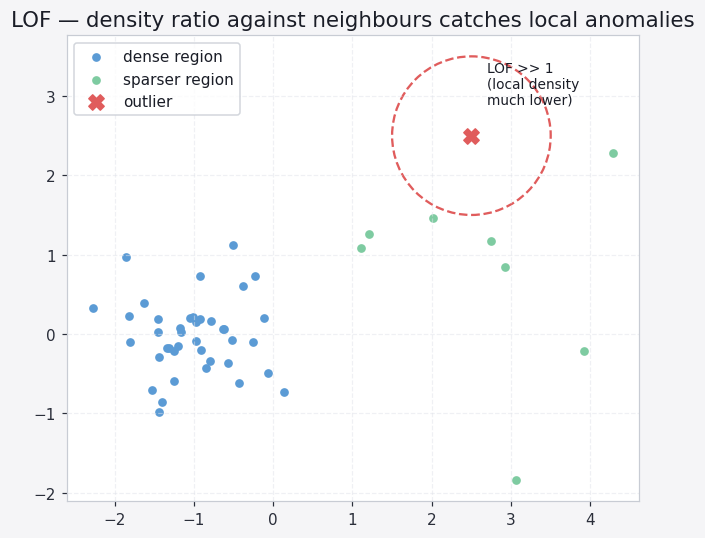

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
dense = rng.randn(40, 2)*0.5 + np.array([-1, 0])
sparse = rng.randn(8, 2)*1.2  + np.array([2.5, 0])
outlier = np.array([2.5, 2.5])
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(dense[:,0], dense[:,1], s=22, color=P[0], label='dense region')
ax.scatter(sparse[:,0], sparse[:,1], s=22, color=P[3], label='sparser region')
ax.scatter(*outlier, s=100, color=P[1], marker='X', label='outlier')
ax.add_patch(Circle(outlier, 1.0, fill=False, lw=1.5, ls='--', edgecolor=P[1]))
ax.text(*outlier+np.array([0.2, 0.4]), 'LOF >> 1\n(local density\nmuch lower)', fontsize=9)
ax.set_aspect('equal'); ax.set_title('LOF — density ratio against neighbours catches local anomalies')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.datasets import make_blobs

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

rng = np.random.default_rng(7)
# Two clusters of very different density + scattered outliers
X_dense, _  = make_blobs(n_samples=160, centers=[(0,0)],  cluster_std=0.35, random_state=1)
X_sparse, _ = make_blobs(n_samples=80,  centers=[(4,4)],  cluster_std=1.20, random_state=2)
X_out = rng.uniform(-3, 7, size=(15, 2))
X = np.vstack([X_dense, X_sparse, X_out])
y_true = np.r_[np.ones(len(X_dense)+len(X_sparse)), -np.ones(len(X_out))]

xx, yy = np.meshgrid(np.linspace(-4,8,260), np.linspace(-4,8,260))
print('Dataset:', X.shape)

Dataset: (255, 2)


---
## Building Blocks — $k$-Distance and Reachability

Pick a neighborhood size $k$. For point $x$:

- $k$**-distance**: distance to its $k$-th nearest neighbor — the radius of the local sphere containing those neighbors.
- **Reachability distance**: $\text{reach-dist}_k(a, b) = \max\bigl(k\text{-dist}(b),\; \|a - b\|\bigr)$. Floor the actual distance at $b$'s $k$-distance — smooths out within-neighborhood spikes.
- **Local reachability density (lrd)**: inverse of the *average* reach-distance from $x$ to its neighbors. Big lrd = densely packed neighborhood.

$$\text{lrd}_k(x) = \Bigl(\tfrac{1}{|N_k(x)|}\sum_{b\in N_k(x)} \text{reach-dist}_k(x, b)\Bigr)^{-1}$$

The picture below shows $k$-distance circles for three sample points.

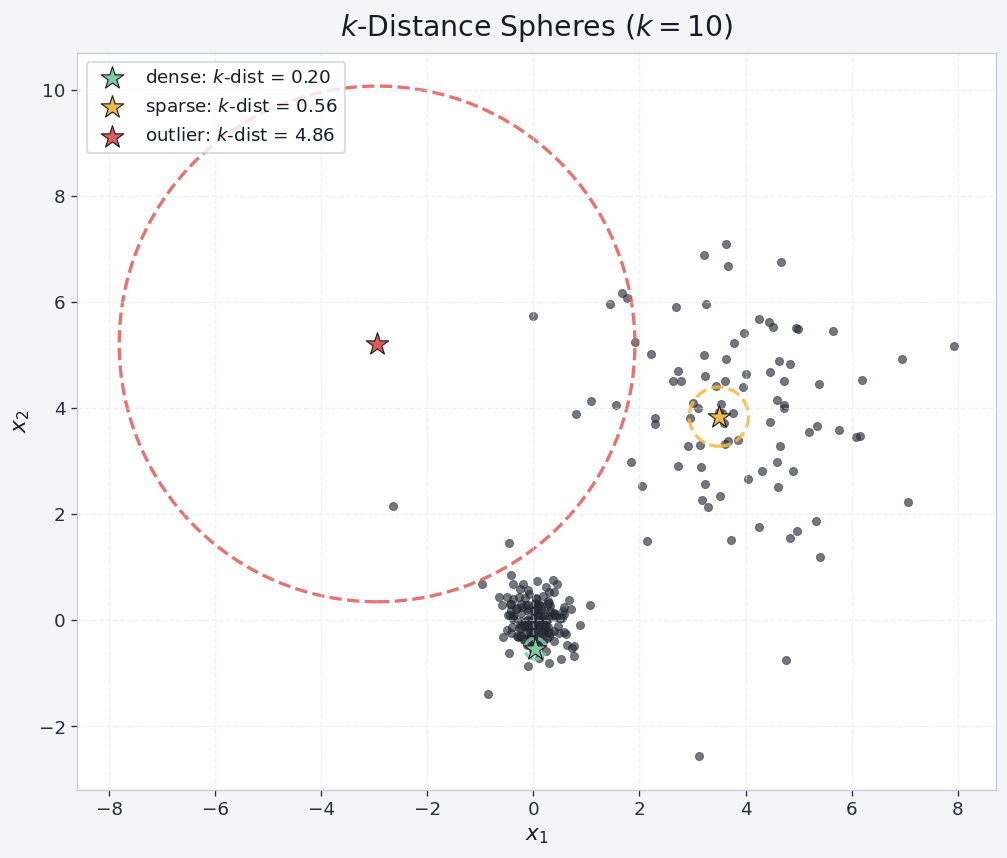

In [3]:
k = 10
nn = NearestNeighbors(n_neighbors=k+1).fit(X)
dists, idx = nn.kneighbors(X)
k_dist = dists[:, k]   # 0-th col is self

fig, ax = plt.subplots(figsize=(8.5, 7.5))
ax.scatter(X[:,0], X[:,1], c='#2a2e3a', s=24, edgecolors='#1a1d27', lw=0.4, alpha=0.65)
for i, (lbl, color) in enumerate(zip(['dense', 'sparse', 'outlier'], [CM, CB, C1])):
    if lbl == 'dense':   pt = X_dense[10]
    elif lbl == 'sparse': pt = X_sparse[10]
    else: pt = X_out[3]
    j = np.argmin(np.linalg.norm(X - pt, axis=1))
    r = k_dist[j]
    circ = plt.Circle(X[j], r, fill=False, color=color, lw=2.0, ls='--', alpha=0.85)
    ax.add_patch(circ)
    ax.scatter(*X[j], s=200, c=color, marker='*', edgecolors='#1a1d27', lw=0.7, zorder=6,
               label=fr'{lbl}: $k$-dist = {r:.2f}')
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
ax.set_title(f'$k$-Distance Spheres ($k = {k}$)', pad=10)
ax.legend(loc='upper left'); ax.grid(True); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

---
## The LOF Score — Density Ratio

$$\text{LOF}_k(x) \;=\; \frac{1}{|N_k(x)|} \sum_{b\in N_k(x)} \frac{\text{lrd}_k(b)}{\text{lrd}_k(x)}$$

- LOF $\approx 1$: $x$ is as dense as its neighbors — normal.
- LOF $\gg 1$: neighbors are much denser than $x$ — $x$ sits in a sparse pocket → anomaly.

Plotting LOF as a heatmap (re-fit at every grid point with `novelty=True`) shows where the model considers density abnormally low.

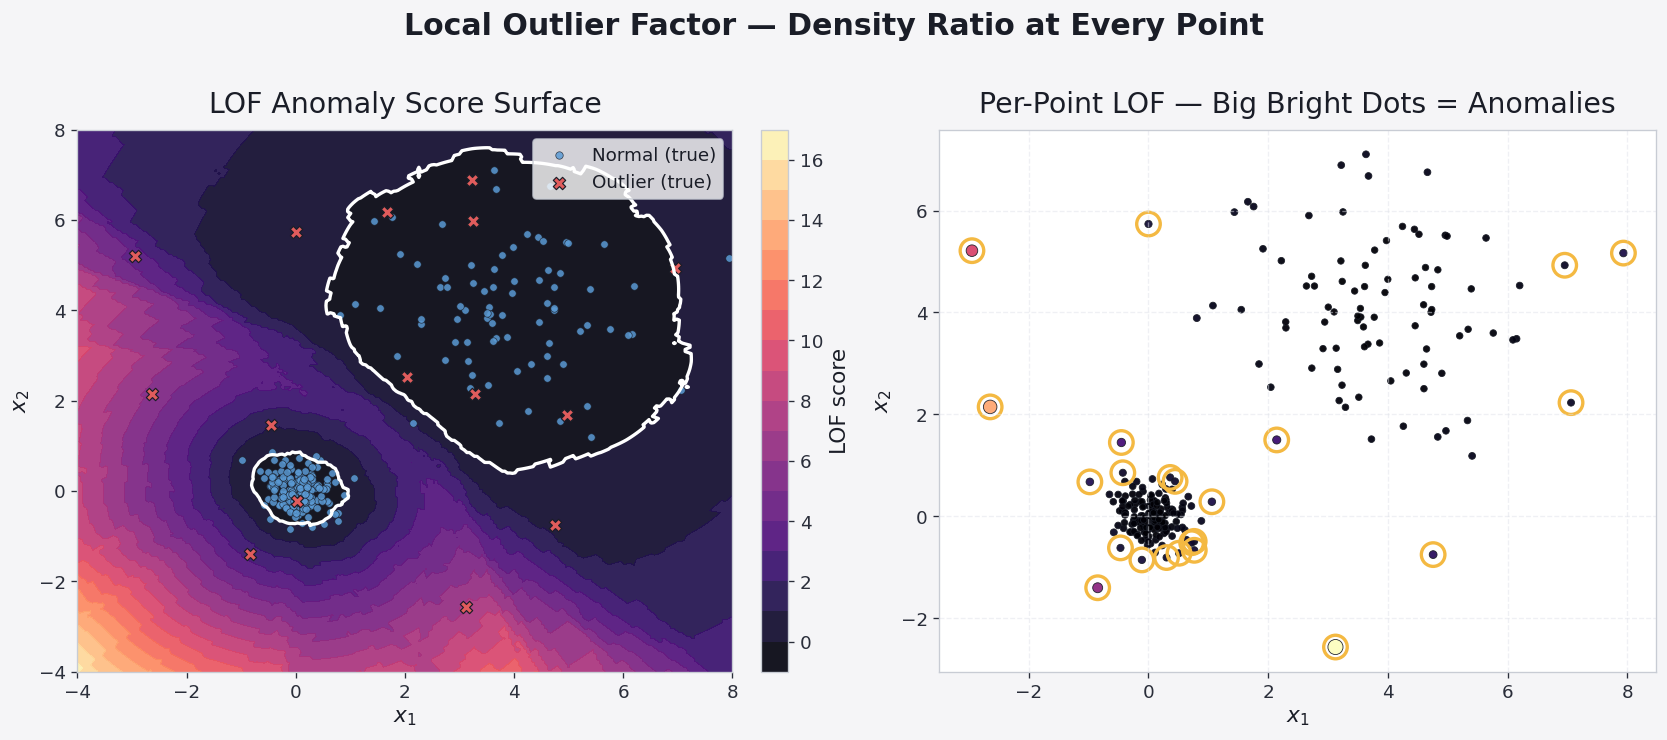

In [4]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.10, novelty=True).fit(X)
score = -lof.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)  # higher = more anomalous
boundary = lof.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
preds = lof.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
cf = ax.contourf(xx, yy, score, levels=18, cmap='magma', alpha=0.92)
ax.contour(xx, yy, boundary, levels=[0], colors='#ffffff', linewidths=2.0)
ax.scatter(X[y_true==1,0],  X[y_true==1,1],  c=C0, s=20, edgecolors='#1a1d27', lw=0.4, alpha=0.85, label='Normal (true)')
ax.scatter(X[y_true==-1,0], X[y_true==-1,1], c=C1, s=55, marker='X', edgecolors='#1a1d27', lw=0.7, label='Outlier (true)')
ax.set_title('LOF Anomaly Score Surface', pad=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.legend(loc='upper right'); ax.grid(False)
plt.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, label='LOF score')

ax = axes[1]
neg = -lof.negative_outlier_factor_
ax.scatter(X[:,0], X[:,1], c=neg, cmap='magma', s=70 * (neg / neg.max())**1.4 + 12,
           edgecolors='#1a1d27', lw=0.5, alpha=0.95)
ax.scatter(X[preds==-1,0], X[preds==-1,1], s=200, facecolors='none', edgecolors=CB, lw=2)
ax.set_title('Per-Point LOF — Big Bright Dots = Anomalies', pad=10)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

fig.suptitle('Local Outlier Factor — Density Ratio at Every Point', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

---
## Effect of `n_neighbors`

$k$ sets the locality scale.
- Too small ($k=3$): density estimate is noisy; even some inliers get high LOF.
- Just right ($k\sim20$): the dense cluster, the sparse cluster, and the outliers separate cleanly.
- Too large ($k=80$): the neighborhood spans both clusters; LOF flattens and the score loses discrimination.

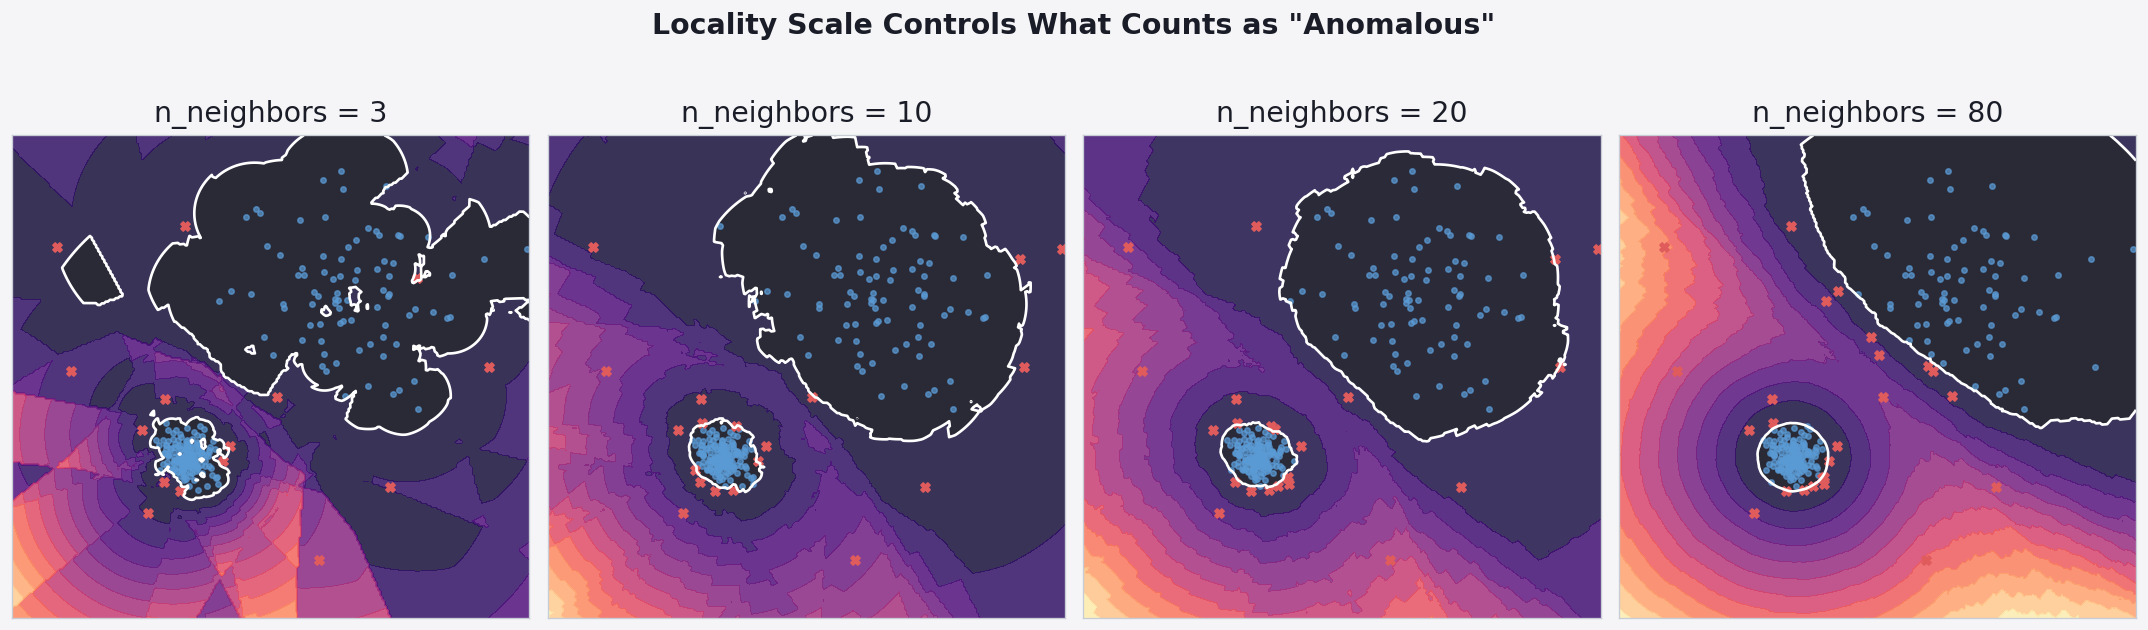

In [5]:
ks = [3, 10, 20, 80]
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, kk in zip(axes, ks):
    m = LocalOutlierFactor(n_neighbors=kk, contamination=0.10, novelty=True).fit(X)
    s = m.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    p = m.predict(X)
    ax.contourf(xx, yy, -s, levels=14, cmap='magma', alpha=0.85)
    ax.contour(xx, yy, s, levels=[0], colors='#ffffff', linewidths=1.6)
    ax.scatter(X[p==1,0],  X[p==1,1],  c=C0, s=10, alpha=0.7)
    ax.scatter(X[p==-1,0], X[p==-1,1], c=C1, s=30, marker='X')
    ax.set_title(f'n_neighbors = {kk}', pad=8); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Locality Scale Controls What Counts as "Anomalous"', fontsize=17, fontweight='bold', y=1.04)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use LOF — and when not to

| Situation | LOF | Isolation Forest | OCSVM |
|---|---|---|---|
| Outliers defined **locally** | ✅ | partial | ❌ |
| Variable-density data | ✅ comparison normalises | ❌ global threshold | ❌ |
| Big data ($n > 100\,000$) | ❌ $O(n^2)$ neighbours | ✅ | ✅ |
| Online / streaming setting | ❌ refit needed | partial | partial |

> LOF wins when "outlier" is a **relative** concept: a point is anomalous because *its neighbours* are denser than it is.


---
## 🎯 Try this

1. **Mixed-density blobs.** Put a tight cluster of 50 points next to a sparse cluster of 50. Try a global density threshold — it fails. LOF labels both clusters' edges correctly.
2. **`n_neighbors` sensitivity.** Sweep `n_neighbors` $\in \{5, 20, 100\}$. Tiny $k$ → noisy LOF; huge $k$ → smoothed scores that miss small anomalies.
3. **Novelty mode.** With `novelty=True` you can score new points. Fit on training inliers only, then predict on a fresh batch with injected outliers — measure ROC-AUC.


---
## Why LOF Beats a Global Threshold

A point at the *edge* of a sparse cluster might be twice as far from its neighbors as a point in the *core* of a dense cluster — yet both can be perfectly normal *for their region*. A global density threshold flags both or neither; LOF's **ratio** to local density correctly normalises and only flags the genuine outliers in the gap.

## Summary

| Concept | Description | Key Insight |
|---|---|---|
| $k$-distance | Radius to $k$-th neighbor | Local scale around each point |
| Reachability dist. | Floor of $\|a-b\|$ at $k$-dist of $b$ | Smooths in-cluster spikes |
| lrd | Inverse mean reach-distance | Local density estimate |
| LOF | Mean ratio neighbours' lrd / point's lrd | $\approx 1$ normal, $\gg 1$ anomaly |
| Strength | Adapts to varying density | No single threshold needed |
| Weakness | Sensitive to $k$; $O(m^2)$ on plain LOF | Pre-pick $k$ from domain knowledge |

**Bottom line:** LOF is the right tool when normal data has **multiple regimes of density**. It scores anomalies by how *unusually empty* their neighborhood is compared to the points around them.